In [1]:
import sqlite3
import pandas as pd
from tqdm import tqdm
import powerlaw as pwl
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


In [2]:
con = sqlite3.connect("../vp_data2_isikud.db")
cur = con.cursor()
cur.execute('ATTACH DATABASE "../v33.db" AS v33')

In [3]:
query = """
SELECT * from 
transaction_v2_obl_root_eluskoht_counts
"""

source3 = pd.read_sql_query(query, con)
#source3

In [4]:
source3["elus_div"] = source3["elus_cnt"]/source3["lemma_cnt"]
source3["koht_div"] = source3["koht_cnt"]/source3["lemma_cnt"]

In [12]:
areadict = {}
root_cnts = sorted(list(set(list(source3["lemma_cnt"])))) # 1-21K

for cnt in root_cnts:
    if cnt <10: areadict[cnt] = 1
    elif cnt >=10 and cnt < 100: areadict[cnt] = 5
    elif cnt >=100 and cnt < 1000: areadict[cnt] = 10
    #elif cnt >=500 and cnt < 1000: areadict[cnt] = 30
    elif cnt >=1000 and cnt < 5000: areadict[cnt] = 30
    #elif cnt >=2000 and cnt < 5000: areadict[cnt] = 80
    elif cnt >=5000 and cnt < 20000: areadict[cnt] = 800
    #elif cnt >=10000 and cnt < 15000: areadict[cnt] = 300
    elif cnt >=20000 and cnt < 50000: areadict[cnt] = 100
    elif cnt >=50000: areadict[cnt] = 300

### normaliseeritud väärtustega pilt

In [19]:
roots = list(source3["lemma_cnt"])
kohad =  list(source3["koht_div"])
elusad = list(source3["elus_div"])

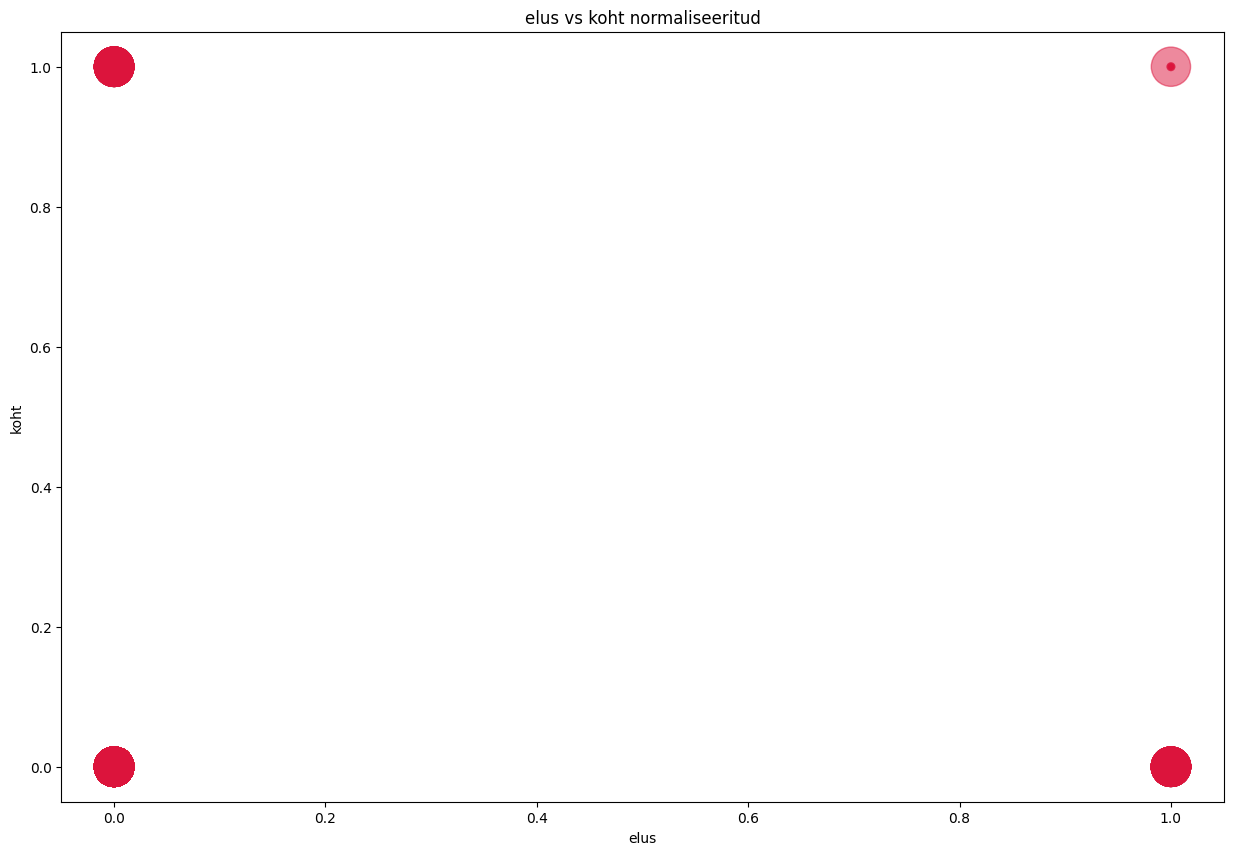

In [20]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)

plt.title("elus vs koht normaliseeritud")
plt.ylabel("koht")
plt.xlabel("elus")

plt.show()

### esialgsed väärtused

In [21]:
roots = list(source3["lemma_cnt"])
kohad =  list(source3["koht_cnt"])
elusad = list(source3["elus_cnt"])

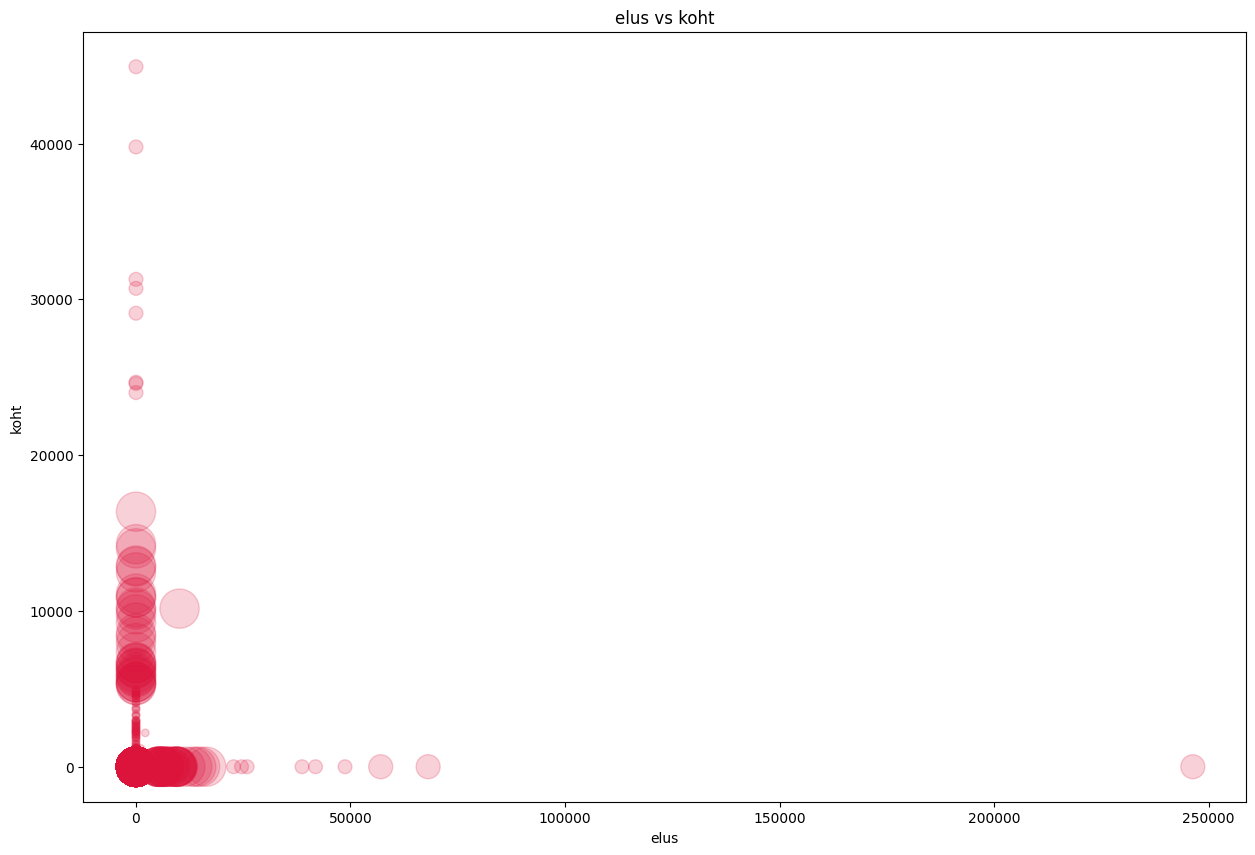

In [22]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad

area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.2)

plt.title("elus vs koht")
plt.ylabel("koht")
plt.xlabel("elus")

plt.show()

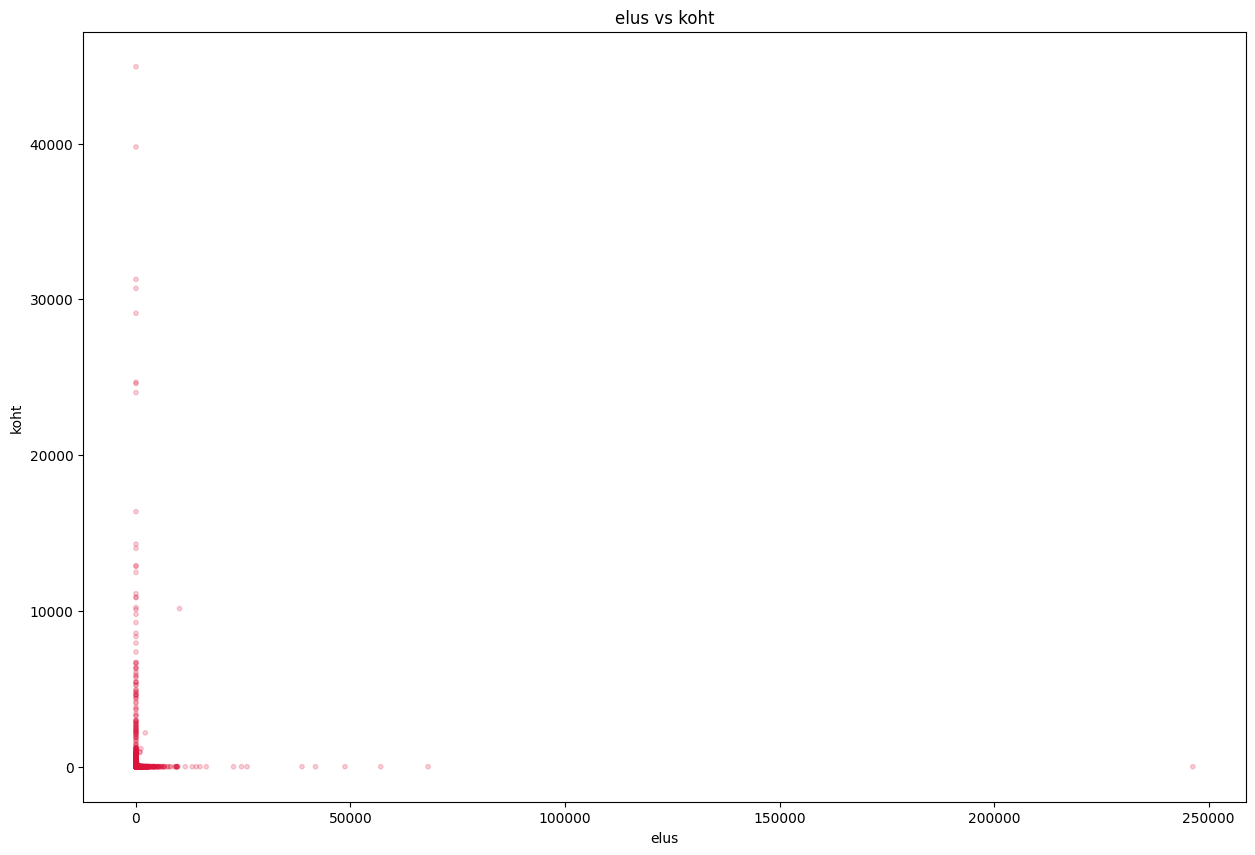

In [23]:
plt.figure(figsize=(15, 10))
x = elusad
y = kohad

area = [10]*len(roots) #[areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.2)

plt.title("elus vs koht")
plt.ylabel("koht")
plt.xlabel("elus")

plt.show()

## esialgsed väärtused aga jätta välja need, kus elus/koht on mõlemad 0

### ehk alles jäävad need, mille puhul on suurem osa elus=koht cnt sest mõni sõna on mõlemas nimekirjas

In [27]:
source4 = source3[(source3["elus_cnt"]!=0) & (source3["koht_cnt"]!=0)]

In [28]:
roots = list(source4["lemma_cnt"])
kohad =  list(source4["koht_cnt"])
elusad = list(source4["elus_cnt"])

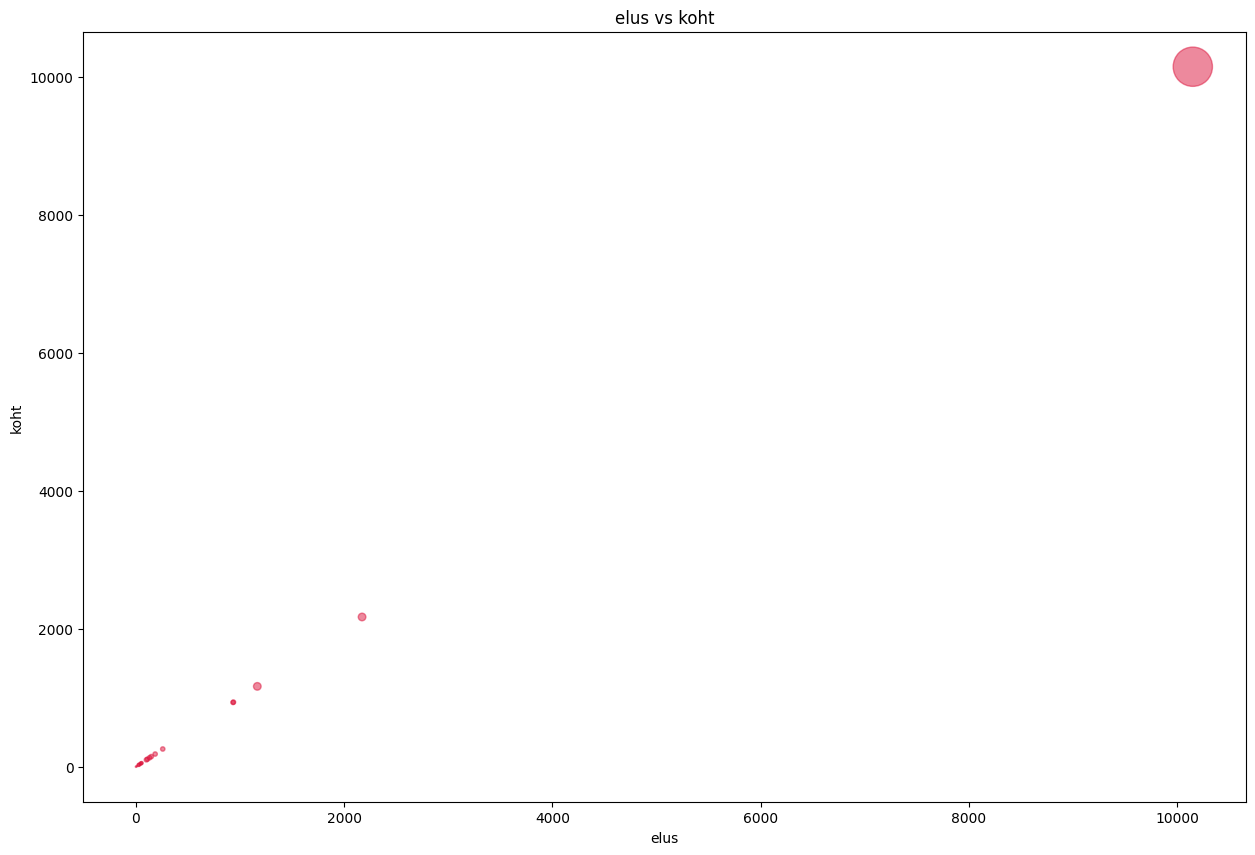

In [30]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad

area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)

plt.title("elus vs koht")
plt.ylabel("koht")
plt.xlabel("elus")

plt.show()

## esialgsed väärtused aga jätta välja need, kus elus/koht on mõlemad 0

### ehk alles jäävad need, mille kus elus või koht on suurem kui 0 (välistada koht==0 ja elus==0)

In [33]:
source4 = source3[(source3["elus_cnt"]!=0) | (source3["koht_cnt"]!=0)]

In [35]:
roots = list(source4["lemma_cnt"])
kohad =  list(source4["koht_cnt"])
elusad = list(source4["elus_cnt"])

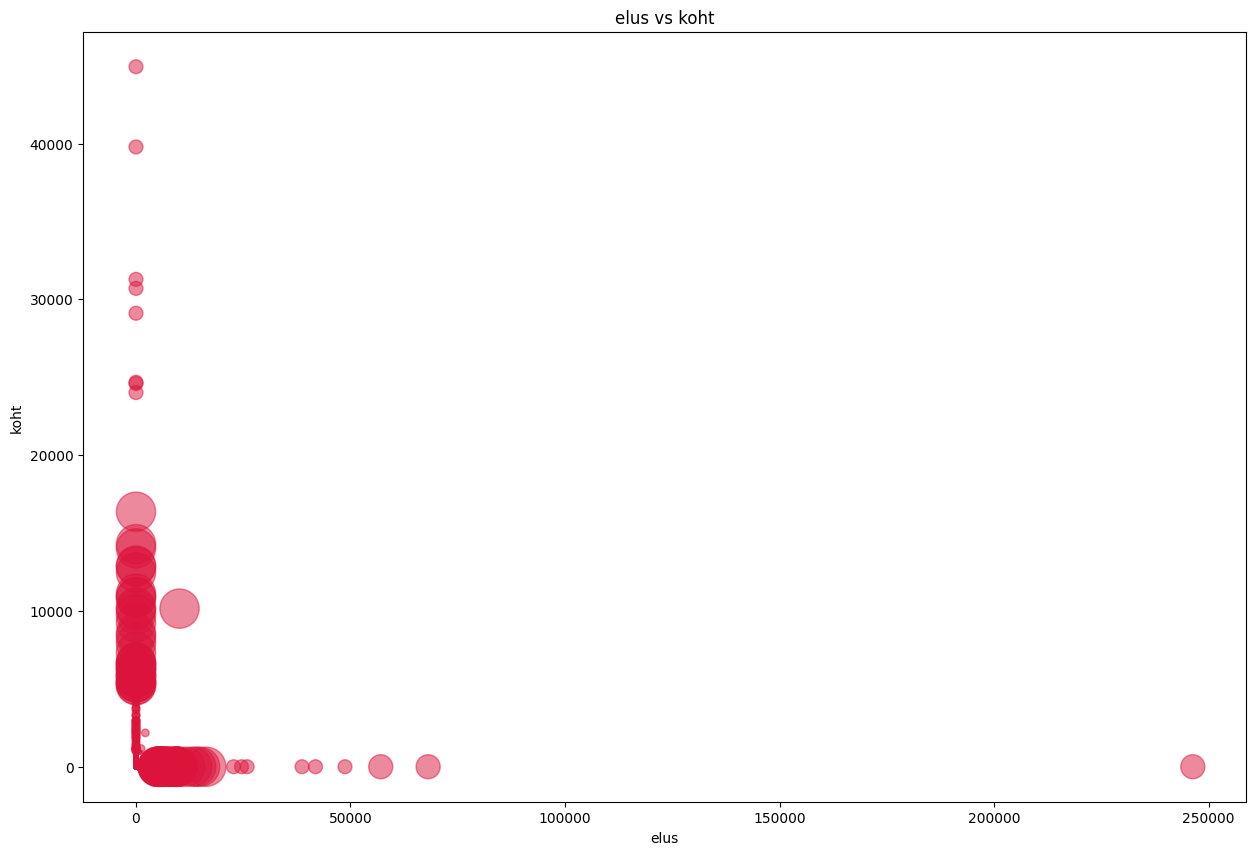

In [36]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)

plt.title("elus vs koht")
plt.ylabel("koht")
plt.xlabel("elus")

plt.show()

#### ja panna piirang lemma_cnt < 20K

In [37]:
source4 = source3[(source3["elus_cnt"]!=0) | (source3["koht_cnt"]!=0)]
source4 = source4[source4["lemma_cnt"]<20000]

In [38]:
roots = list(source4["lemma_cnt"])
kohad =  list(source4["koht_cnt"])
elusad = list(source4["elus_cnt"])

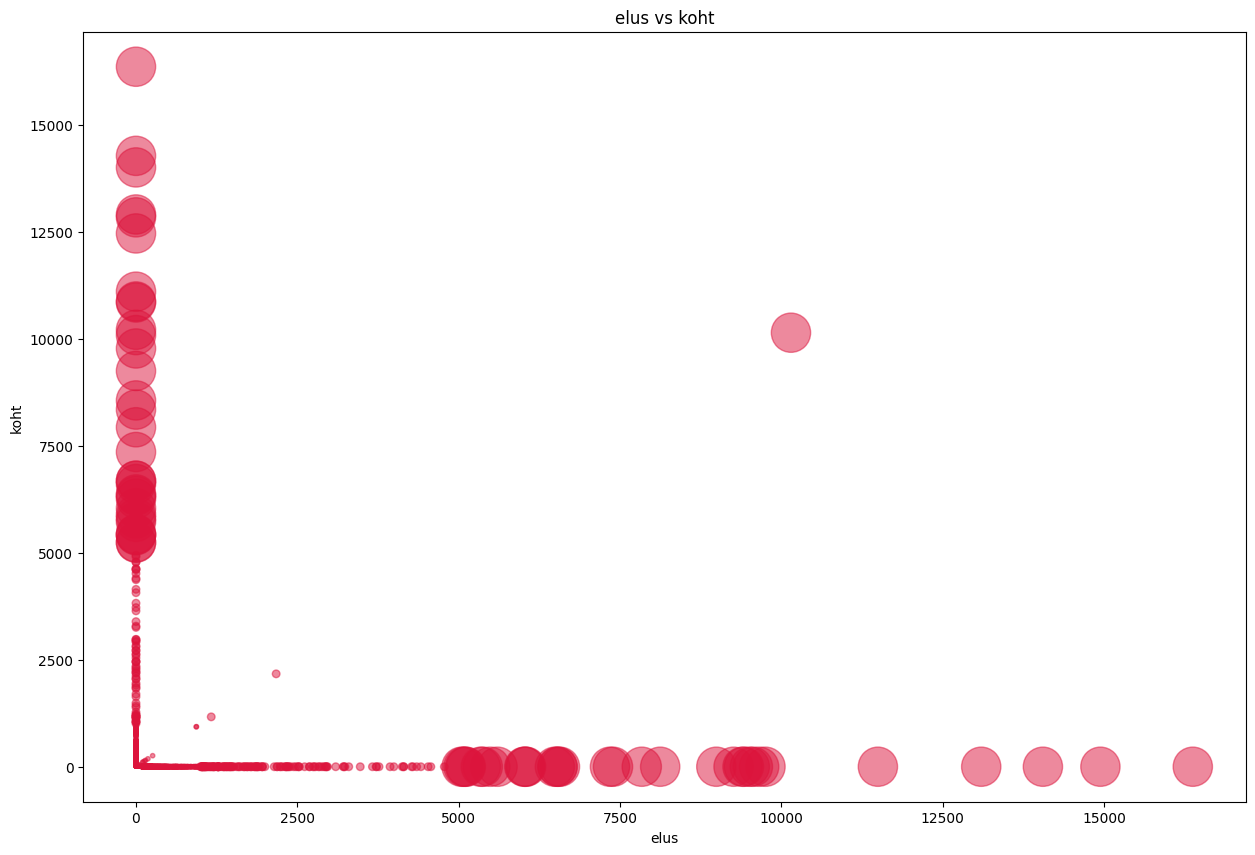

In [39]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad

area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)

plt.title("elus vs koht")
plt.ylabel("koht")
plt.xlabel("elus")

plt.show()

## esialgsed väärtused aga lemma_cnt < 20K

In [24]:
source4 = source3[source3["lemma_cnt"]<20000]

In [25]:
roots = list(source4["lemma_cnt"])
kohad =  list(source4["koht_cnt"])
elusad = list(source4["elus_cnt"])

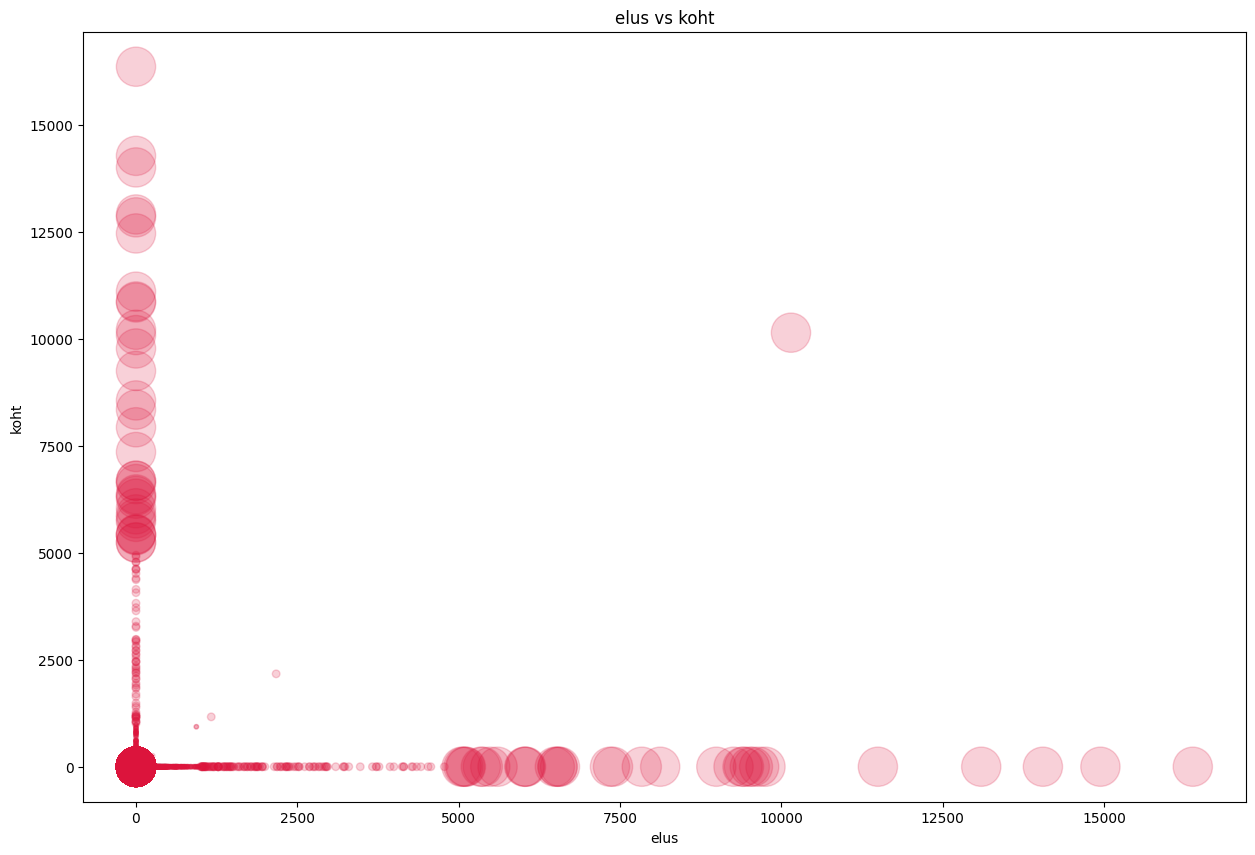

In [26]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad

area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.2)

plt.title("elus vs koht")
plt.ylabel("koht")
plt.xlabel("elus")

plt.show()

In [40]:
con.close()